In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [5]:
df = pd.read_csv("clinical_trials_raw_patient2trial_conditions.csv")

In [7]:
df.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [8]:
df.tail()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
60332,sickle cell anemia,NCT03293641,Zinc Supplementation in Children With Sickle C...,The Effects of Zinc Supplementation in Childre...,Zinc is a nutritionally essential trace elemen...,Sickle Cell Disease | Zinc Deficiency | Infection,Zinc Sulfate Tablets | Standard of Care,COMPLETED,INTERVENTIONAL,NaN,ALL,6 Months,12 Years,False,Inclusion Criteria:\n\n* Male or female infant...,https://clinicaltrials.gov/study/NCT03293641
60333,sickle cell anemia,NCT02197845,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Enhancing Use of Hydroxyurea In Sickle Cell Di...,"Multi-phase, patient navigator-based program i...",Sickle Cell Disease,Patient Navigator | Recruitment into Specialty...,COMPLETED,INTERVENTIONAL,NaN,ALL,15 Years,NaN,False,PHASE I:\n\nInclusion Criteria:\n\n* Patient S...,https://clinicaltrials.gov/study/NCT02197845
60334,sickle cell anemia,NCT01718054,Vascular Function Intervention Trial in Sickle...,Development of a Ready-to-use Nutraceutical Fo...,Sickle cell disease (SCD) is the most common i...,Sickle Cell Disease,Vascular ready-to-use supplementary food | Reg...,UNKNOWN,INTERVENTIONAL,PHASE2 | PHASE3,ALL,8 Years,11 Years,False,Inclusion Criteria:\n\n* Aged 8-11 years old a...,https://clinicaltrials.gov/study/NCT01718054
60335,sickle cell anemia,NCT06647979,Hematopoietic Stem Cell BCL11A Enhancer Gene E...,An Adaptive Design Basket Trial of Hematopoiet...,A promising approach for the treatment of gene...,Sickle Cell Disease | Sickle Cell Anemia (HbSS...,autologous bone marrow derived CD34+ HSPCs ele...,RECRUITING,INTERVENTIONAL,PHASE1,ALL,13 Years,40 Years,False,Inclusion Criteria:\n\n1. Diagnosis of either ...,https://clinicaltrials.gov/study/NCT06647979
60336,sickle cell anemia,NCT06158945,The Role of Endothelin 1 as a Marker of Renal ...,The Role of Endothelin 1 as a Marker of Renal ...,Sickle cell disease (SCD) refers to a group of...,Sickle Cell Disease,urinary endothelin 1,UNKNOWN,OBSERVATIONAL,NaN,ALL,1 Year,18 Years,True,Inclusion Criteria:\n\n* The patients fulfilli...,https://clinicaltrials.gov/study/NCT06158945


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [10]:
df.dtypes

source_condition_query       str
nct_id                       str
title                        str
official_title               str
brief_summary                str
conditions                   str
interventions                str
overall_status               str
study_type                   str
phase                        str
sex                          str
minimum_age                  str
maximum_age                  str
healthy_volunteers        object
eligibility_criteria         str
clinicaltrials_url           str
dtype: object

In [11]:
df.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [16]:
df_clean = df[['brief_summary', 'source_condition_query']].copy()


In [23]:
df_clean.duplicated().sum()

np.int64(265)

In [13]:
print(df_clean.shape)
print(df_clean.head())

(60337, 2)
                                       brief_summary source_condition_query
0  Breast cancer patients often have perioperativ...          breast cancer
1  Many breast cancer patients experience psychol...          breast cancer
2  Based on an American study by Scherer et al., ...          breast cancer
3  Compare the effect of ropivacaine versus place...          breast cancer
4  Phase 1 dose escalation and expansion study of...          breast cancer


In [14]:
print(df_clean.isnull().sum())

brief_summary             0
source_condition_query    0
dtype: int64


In [15]:
print("Before:", df_clean.shape)
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)

Before: (60337, 2)
After removing duplicates: (60072, 2)


In [24]:
df_clean['summary_length'] = df_clean['brief_summary'].str.len()
print(df_clean['summary_length'].describe())

count    60337.000000
mean       688.297396
std        630.584628
min         17.000000
25%        253.000000
50%        466.000000
75%        904.000000
max       5011.000000
Name: summary_length, dtype: float64


C:\Users\SPLPT 274\AppData\Local\Temp\ipykernel_8768\3905497136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='source_condition_query', data=df,


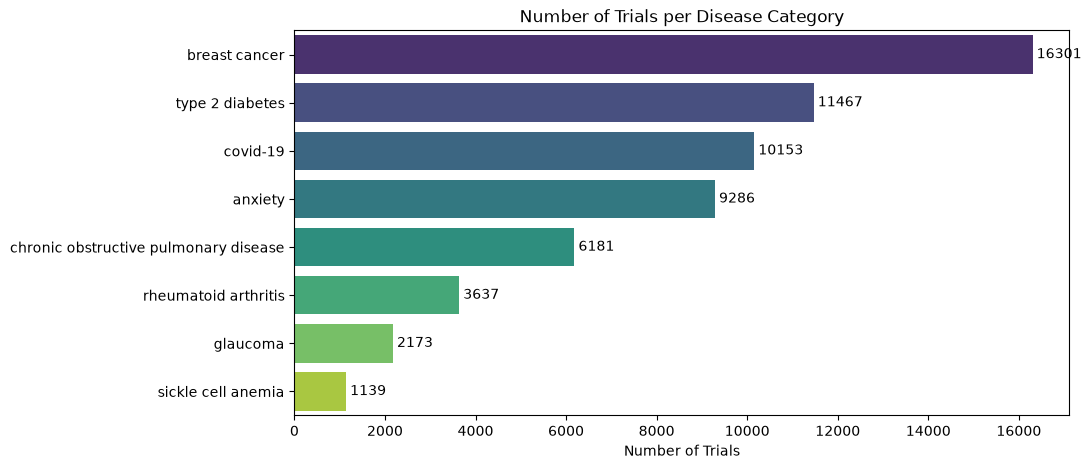

In [59]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(y='source_condition_query', data=df,
                   order=df['source_condition_query'].value_counts().index, palette='viridis')
plt.title('Number of Trials per Disease Category')
plt.xlabel('Number of Trials')
plt.ylabel('')
for c in ax.containers:
    ax.bar_label(c, padding=3)
plt.show()

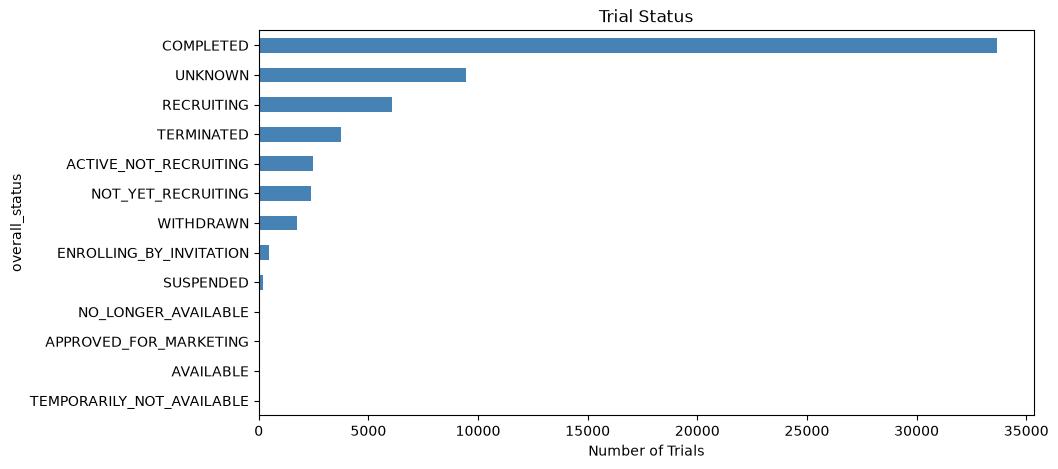

In [60]:
plt.figure(figsize=(10, 5))
df['overall_status'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Trial Status')
plt.xlabel('Number of Trials')
plt.gca().invert_yaxis()
plt.show()

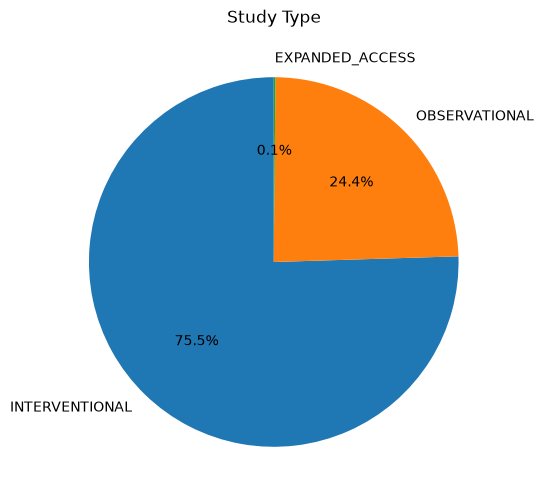

In [61]:
plt.figure(figsize=(6, 6))
df['study_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Study Type')
plt.ylabel('')
plt.show()

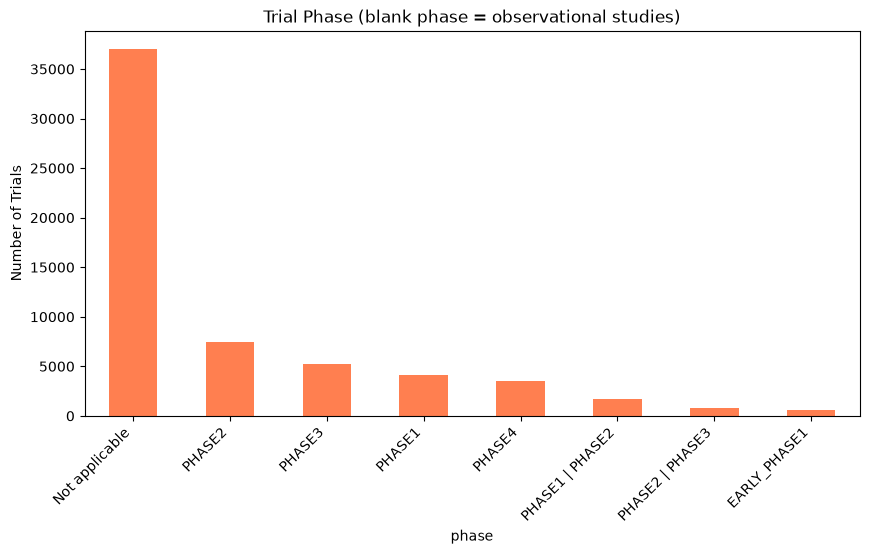

In [62]:
plt.figure(figsize=(10, 5))
df['phase'].fillna('Not applicable').value_counts().plot(kind='bar', color='coral')
plt.title('Trial Phase (blank phase = observational studies)')
plt.ylabel('Number of Trials')
plt.xticks(rotation=45, ha='right')
plt.show()

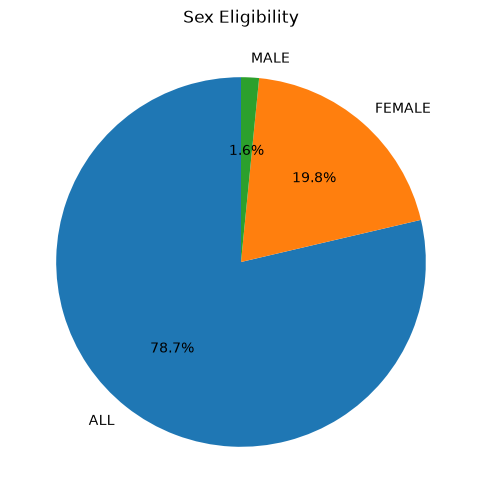

In [63]:
plt.figure(figsize=(6, 6))
df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sex Eligibility')
plt.ylabel('')
plt.show()

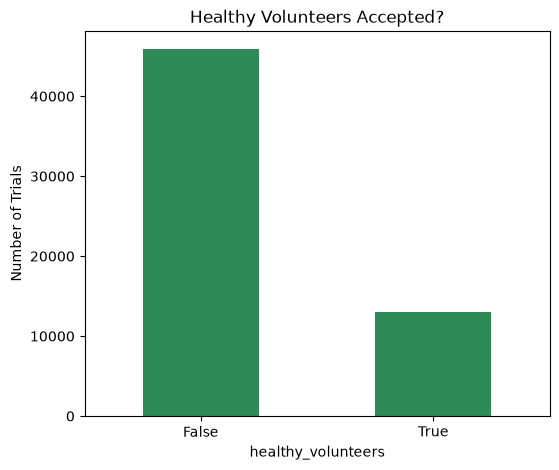

In [64]:
plt.figure(figsize=(6, 5))
df['healthy_volunteers'].astype(str).value_counts().plot(kind='bar', color='seagreen')
plt.title('Healthy Volunteers Accepted?')
plt.ylabel('Number of Trials')
plt.xticks(rotation=0)
plt.show()

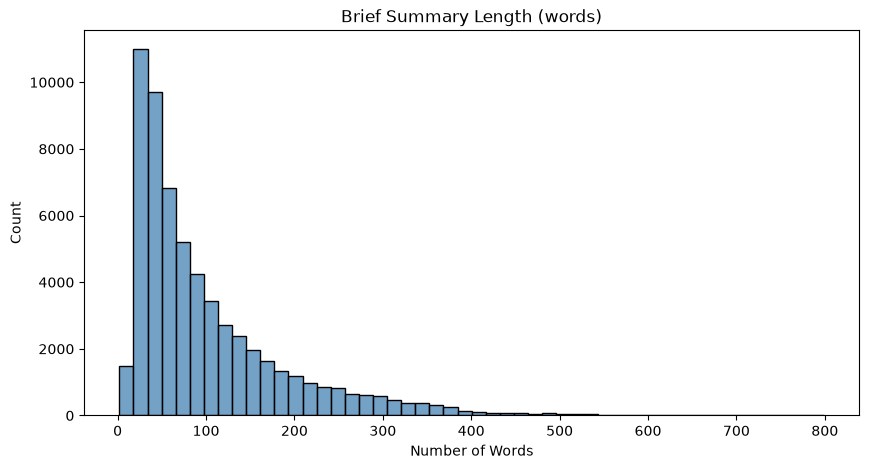

In [65]:
df['summary_words'] = df['brief_summary'].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df['summary_words'], bins=50, color='steelblue')
plt.title('Brief Summary Length (words)')
plt.xlabel('Number of Words')
plt.show()

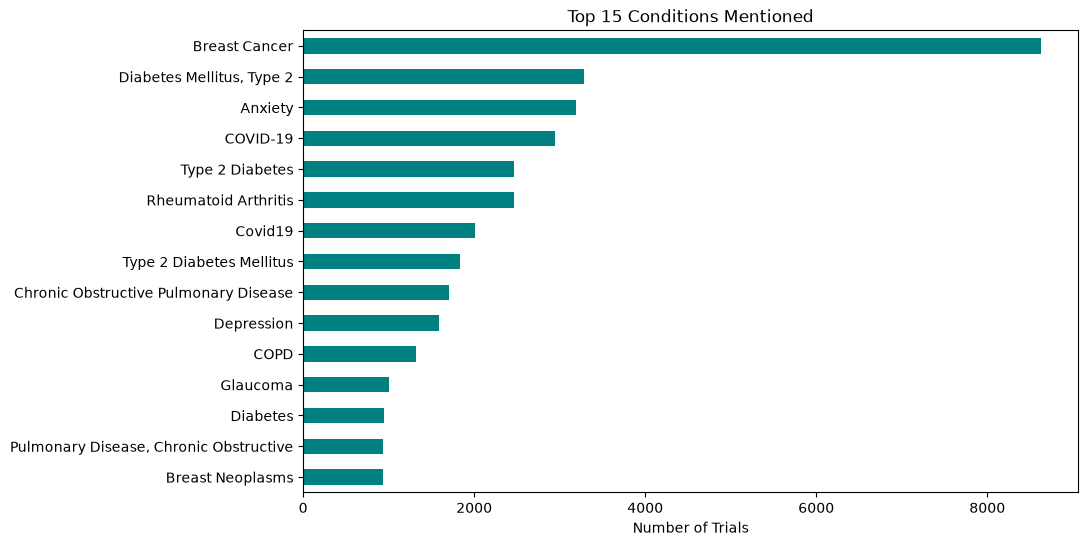

In [68]:
condition_counts = Counter()
for row in df['conditions'].dropna():
    for item in row.split(' | '):
        condition_counts[item.strip()] += 1

top_conditions = pd.Series(dict(condition_counts.most_common(15)))

plt.figure(figsize=(10, 6))
top_conditions.sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Conditions Mentioned')
plt.xlabel('Number of Trials')
plt.show()

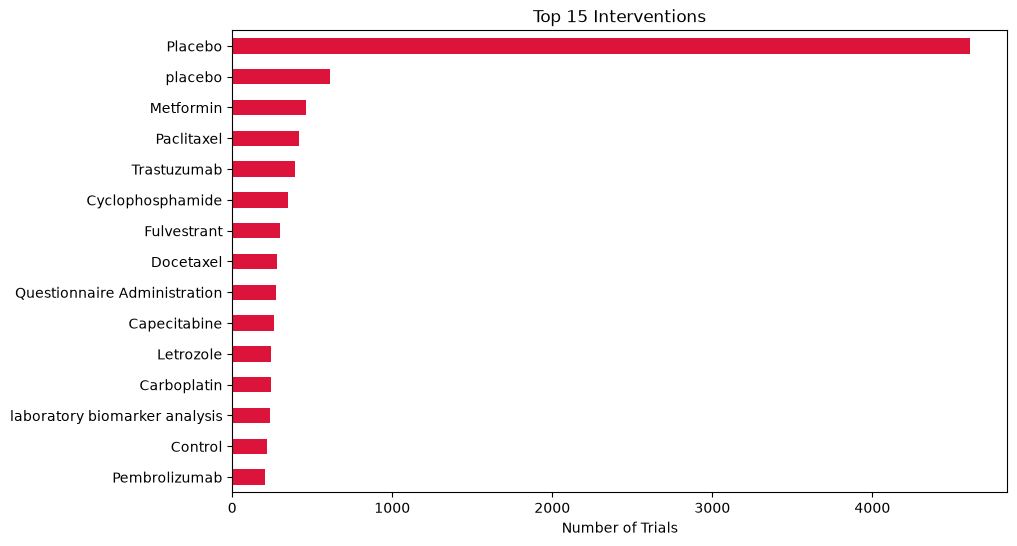

In [69]:
intervention_counts = Counter()
for row in df['interventions'].dropna():
    for item in row.split(' | '):
        intervention_counts[item.strip()] += 1

top_interventions = pd.Series(dict(intervention_counts.most_common(15)))

plt.figure(figsize=(10, 6))
top_interventions.sort_values().plot(kind='barh', color='crimson')
plt.title('Top 15 Interventions')
plt.xlabel('Number of Trials')
plt.show()

In [26]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to C:\Users\SPLPT
[nltk_data]     274\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\SPLPT
[nltk_data]     274\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\SPLPT
[nltk_data]     274\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\SPLPT
[nltk_data]     274\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to C:\Users\SPLPT
[nltk_data]     274\AppData\Roaming\nltk_data...


In [27]:
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['cleaned_summary'] = df_clean['brief_summary'].apply(clean_text)
print(df_clean[['brief_summary', 'cleaned_summary']].head())

                                       brief_summary  \
0  Breast cancer patients often have perioperativ...   
1  Many breast cancer patients experience psychol...   
2  Based on an American study by Scherer et al., ...   
3  Compare the effect of ropivacaine versus place...   
4  Phase 1 dose escalation and expansion study of...   

                                     cleaned_summary  
0  breast cancer patients often have perioperativ...  
1  many breast cancer patients experience psychol...  
2  based on an american study by scherer et al it...  
3  compare the effect of ropivacaine versus place...  
4  phase dose escalation and expansion study of c...  


In [28]:
def tokenize_text(text):
    return word_tokenize(text)

df_clean['tokens'] = df_clean['cleaned_summary'].apply(tokenize_text)
print(df_clean[['cleaned_summary', 'tokens']].head())

                                     cleaned_summary  \
0  breast cancer patients often have perioperativ...   
1  many breast cancer patients experience psychol...   
2  based on an american study by scherer et al it...   
3  compare the effect of ropivacaine versus place...   
4  phase dose escalation and expansion study of c...   

                                              tokens  
0  [breast, cancer, patients, often, have, periop...  
1  [many, breast, cancer, patients, experience, p...  
2  [based, on, an, american, study, by, scherer, ...  
3  [compare, the, effect, of, ropivacaine, versus...  
4  [phase, dose, escalation, and, expansion, stud...  


In [29]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df_clean['tokens_no_stopwords'] = df_clean['tokens'].apply(remove_stopwords)
print(df_clean[['tokens', 'tokens_no_stopwords']].head())

                                              tokens  \
0  [breast, cancer, patients, often, have, periop...   
1  [many, breast, cancer, patients, experience, p...   
2  [based, on, an, american, study, by, scherer, ...   
3  [compare, the, effect, of, ropivacaine, versus...   
4  [phase, dose, escalation, and, expansion, stud...   

                                 tokens_no_stopwords  
0  [breast, cancer, patients, often, perioperativ...  
1  [many, breast, cancer, patients, experience, p...  
2  [based, american, study, scherer, et, al, hypo...  
3  [compare, effect, ropivacaine, versus, placebo...  
4  [phase, dose, escalation, expansion, study, cl...  


In [30]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_clean['lemmatized_tokens'] = df_clean['tokens_no_stopwords'].apply(lemmatize_tokens)
print(df_clean[['tokens_no_stopwords', 'lemmatized_tokens']].head())

                                 tokens_no_stopwords  \
0  [breast, cancer, patients, often, perioperativ...   
1  [many, breast, cancer, patients, experience, p...   
2  [based, american, study, scherer, et, al, hypo...   
3  [compare, effect, ropivacaine, versus, placebo...   
4  [phase, dose, escalation, expansion, study, cl...   

                                   lemmatized_tokens  
0  [breast, cancer, patient, often, perioperative...  
1  [many, breast, cancer, patient, experience, ps...  
2  [based, american, study, scherer, et, al, hypo...  
3  [compare, effect, ropivacaine, versus, placebo...  
4  [phase, dose, escalation, expansion, study, cl...  


In [31]:
df_clean['final_text'] = df_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))
print(df_clean[['brief_summary', 'final_text']].head())

                                       brief_summary  \
0  Breast cancer patients often have perioperativ...   
1  Many breast cancer patients experience psychol...   
2  Based on an American study by Scherer et al., ...   
3  Compare the effect of ropivacaine versus place...   
4  Phase 1 dose escalation and expansion study of...   

                                          final_text  
0  breast cancer patient often perioperative emot...  
1  many breast cancer patient experience psycholo...  
2  based american study scherer et al hypothesize...  
3  compare effect ropivacaine versus placebo pect...  
4  phase dose escalation expansion study clsp fir...  


In [33]:
df_clean['brief_summary'].head()

0    Breast cancer patients often have perioperativ...
1    Many breast cancer patients experience psychol...
2    Based on an American study by Scherer et al., ...
3    Compare the effect of ropivacaine versus place...
4    Phase 1 dose escalation and expansion study of...
Name: brief_summary, dtype: str

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df_clean['final_text'])

print(X_tfidf.shape)

(60337, 5000)


In [43]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2471497 stored elements and shape (60337, 5000)>

In [36]:
print(df_clean[ 'final_text'].head(10))

0    breast cancer patient often perioperative emot...
1    many breast cancer patient experience psycholo...
2    based american study scherer et al hypothesize...
3    compare effect ropivacaine versus placebo pect...
4    phase dose escalation expansion study clsp fir...
5    purpose study conduct month randomized control...
6    pilot study main purpose study see relationshi...
7    goal experimental study compare mammogram rate...
8    goal clinical trial compare effectiveness ultr...
9    study evaluates change quality life treatment ...
Name: final_text, dtype: str


In [37]:
print("ORIGINAL:")
print(df_clean['brief_summary'].iloc[0])
print("\nFINAL PROCESSED:")
print(df_clean['final_text'].iloc[0])

ORIGINAL:
Breast cancer patients often have perioperative emotional disorders such as anxiety and depression, which can lead to poor quality of recovery.This study aims to determine whether ketamine could improve the quality of recovery in breast cancer patients. Meanwhile, it will show if ketamine could improve anxiety, depression, postoperative pain and fatigue.This trial also will bring great concerns on patients' mental health perioperatively and explore the measures to improve their quality of life.

FINAL PROCESSED:
breast cancer patient often perioperative emotional disorder anxiety depression lead poor quality recoverythis study aim determine whether ketamine could improve quality recovery breast cancer patient meanwhile show ketamine could improve anxiety depression postoperative pain fatiguethis trial also bring great concern patient mental health perioperatively explore measure improve quality life


In [38]:
print("Empty strings in final_text:", (df_clean['final_text'] == '').sum())

Empty strings in final_text: 0


In [39]:
df_clean['final_length'] = df_clean['final_text'].str.len()
print(df_clean['final_length'].describe())

count    60337.000000
mean       510.283010
std        464.232345
min         12.000000
25%        190.000000
50%        348.000000
75%        670.000000
max       4060.000000
Name: final_length, dtype: float64


In [40]:
from sklearn.preprocessing import LabelEncoder

le_disease = LabelEncoder()
df_clean['disease_label'] = le_disease.fit_transform(df_clean['source_condition_query'])

print(le_disease.classes_)
print(df_clean[['source_condition_query', 'disease_label']].head(10))

['anxiety' 'breast cancer' 'chronic obstructive pulmonary disease'
 'covid-19' 'glaucoma' 'rheumatoid arthritis' 'sickle cell anemia'
 'type 2 diabetes']
  source_condition_query  disease_label
0          breast cancer              1
1          breast cancer              1
2          breast cancer              1
3          breast cancer              1
4          breast cancer              1
5          breast cancer              1
6          breast cancer              1
7          breast cancer              1
8          breast cancer              1
9          breast cancer              1


In [48]:
print(X_tfidf.shape)
print(df_clean['disease_label'].shape)

(60337, 5000)
(60337,)


In [49]:
X = X_tfidf
y = df_clean['disease_label']

In [50]:
print(X.shape[0] == len(y))

True


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(48269, 5000) (12068, 5000)
(48269,) (12068,)


In [56]:
from sklearn.linear_model import LogisticRegression


log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [57]:
from sklearn.metrics import accuracy_score, classification_report
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=le_disease.classes_))

Logistic Regression Accuracy: 0.9425
                                       precision    recall  f1-score   support

                              anxiety       0.89      0.95      0.92      1921
                        breast cancer       0.95      0.97      0.96      3259
chronic obstructive pulmonary disease       0.94      0.89      0.92      1251
                             covid-19       0.96      0.93      0.94      1925
                             glaucoma       0.98      0.92      0.95       456
                 rheumatoid arthritis       0.97      0.88      0.92       738
                   sickle cell anemia       0.97      0.83      0.90       227
                      type 2 diabetes       0.94      0.97      0.96      2291

                             accuracy                           0.94     12068
                            macro avg       0.95      0.92      0.93     12068
                         weighted avg       0.94      0.94      0.94     12068

